# 02_分类算法-支持向量机

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


先简单介绍一下，支持向量机（Support Vector Machine，SVM）用于分类和回归分析。

它最初由Vladimir Vapnik等人在上世纪90年代初提出，是一种有效的监督学习方法，在许多实际问题中取得了很好的效果。

SVM的基本思想是找到一个超平面（在二维空间中就是一条直线，在三维空间中是一个平面，以此类推到更高维的空间），能够将不同类别的数据分开，并且使得最靠近这个超平面的数据点到这个超平面的距离尽可能远。这些最靠近超平面的数据点被称为支持向量，它们决定了超平面的位置和方向。

SVM在处理线性可分的情况下表现出色，但在处理线性不可分的情况下，需要使用一些技巧来将数据映射到高维空间，使其变得线性可分。这些技巧包括核方法（kernel methods），通过核函数将数据映射到高维空间，使得原本在低维空间中线性不可分的问题在高维空间中变得线性可分。

### 理论基础

支持向量机是一种二分类模型，其基本模型是定义在特征空间上的间隔最大的线性分类器，其学习策略是间隔最大化，最终可转化为一个凸二次规划问题的求解。

**1. 线性可分支持向量机**

假设给定线性可分训练数据集$T={(x_1,y_1),(x_2,y_2),...,(x_N,y_N)}$，其中$x_i\in \mathbf{X}=\mathbf{R}^n$，$y_i\in\mathbf{Y}=\{-1,1\}$，$i=1,2,...,N$，线性可分支持向量机（硬间隔支持向量机）通过求解如下凸二次规划问题学习得到分离超平面和分类决策函数：


$$
\min_{w,b} \frac{1}{2} \|w\|^2 \\s.t. \quad y_i(w \cdot x_i + b) \geq 1, \quad i=1,2,...,N
$$


这里，$w$是超平面的法向量，$b$是超平面的截距，$(w,b)$确定了分离超平面：


$$
w \cdot x + b = 0
$$


分类决策函数为：


$$
f(x) = \text{sign}(w \cdot x + b)
$$


其中$\text{sign}(x)$是符号函数，即当$x>0$时为1，$x<0$时为-1，$x=0$时为0。

**2. 线性支持向量机**

对于线性不可分的情况，引入松弛变量$\xi_i \geq 0$，使得不等式约束变为：


$$
y_i(w \cdot x_i + b) \geq 1 - \xi_i, \quad i=1,2,...,N
$$


同时，对每个样本$(x_i, y_i)$引入一个惩罚项$C\xi_i$，$C>0$为惩罚参数，对误分类样本的惩罚。此时，学习的凸二次规划问题变为：


$$
\min_{w,b,\xi} \frac{1}{2} \|w\|^2 + C\sum_{i=1}^{N} \xi_i \\s.t. \quad y_i(w \cdot x_i + b) \geq 1 - \xi_i, \quad \xi_i \geq 0, \quad i=1,2,...,N
$$


**3. 非线性支持向量机**

对于非线性可分的情况，可通过核技巧将输入空间映射到高维特征空间，使得样本在新空间中线性可分。

假设给定核函数$K(x,z)$，则在特征空间中的分类决策函数为：


$$
f(x) = \text{sign}\left(\sum_{i=1}^{N} \alpha_i y_i K(x_i, x) + b\right)
$$


其中，$\alpha_i$为拉格朗日乘子，$b$为偏置项，$K(x,z)$为核函数。通常使用的核函数包括线性核、多项式核、高斯核等。

**算法流程**

1. 支持向量机的学习算法主要包括以下步骤：
2. 对偶问题的求解：构造拉格朗日函数，求其对偶问题的解；
3. 核函数的选择：根据问题的特点选择合适的核函数；
4. 阈值$b$的确定：利用支持向量计算得到；
5. 分类决策函数的构建：根据学习得到的参数计算分类决策函数。

SVM 通过间隔最大化的思想，能够得到较好的泛化能力，并且在处理非线性问题时，通过核技巧能够将原始空间映射到更高维的空间，使得数据线性可分，从而解决了许多实际问题。

### 一个完整案例

使用支持向量机 (SVM) 对鸢尾花数据集进行分类，并进行了算法优化。

Accuracy: 0.9111111111111111
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.85      0.85      0.85        13
           2       0.85      0.85      0.85        13

    accuracy                           0.91        45
   macro avg       0.90      0.90      0.90        45
weighted avg       0.91      0.91      0.91        45



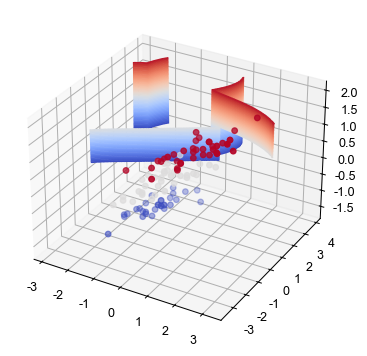

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# 加载鸢尾花数据集
iris = datasets.load_iris()
X = iris.data
y = iris.target

# 为数据添加噪声
random_state = np.random.RandomState(0)
n_samples, n_features = X.shape
X = np.c_[X, random_state.randn(n_samples, 2 * n_features)]

# 将数据集分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 特征缩放
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 初始化支持向量机分类器
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale')

# 在训练集上训练支持向量机模型
svm_clf.fit(X_train_scaled, y_train)

# 在测试集上进行预测
y_pred = svm_clf.predict(X_test_scaled)

# 计算分类准确率
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# 输出分类报告
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 可视化决策边界
def plot_decision_boundary(X, y, classifier):
    h = .02  # 步长
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = classifier.predict(np.c_[xx.ravel(), yy.ravel(), np.zeros_like(xx.ravel())])
    Z = Z.reshape(xx.shape)
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.contour3D(xx, yy, Z, 50, cmap='coolwarm')
    ax.scatter3D(X[:, 0], X[:, 1], X[:, 2], c=y, cmap='coolwarm')
    plt.show()

# 将数据降维到三维进行可视化
X_train_3d = X_train_scaled[:, :3]
svm_clf_3d = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_clf_3d.fit(X_train_3d, y_train)
plot_decision_boundary(X_train_3d, y_train, svm_clf_3d)

![原文参考图，当前结果见代码输出](attachments/img_020.png)

简单解释一下代码，首先，加载了鸢尾花数据集，然后将数据集分割为训练集和测试集。

然后，使用 `StandardScaler` 对数据进行标准化处理。初始化了一个 SVM 分类器，并使用训练集训练了该模型。最后，对测试集进行预测，并计算了分类准确率和分类报告。

此外，还实现了一个函数 `plot_decision_boundary` 用于可视化决策边界。

**算法优化方面**，选择了 RBF 核，并设置了 C 参数和 gamma 参数，这些都是 SVM 中需要调节的关键参数。另外，我们在可视化中将数据降维到二维，并绘制了决策边界，以便更直观地理解模型的分类效果。

### 应用场景

**支持向量机适用于以下类型的问题：**

- 二分类问题：SVM最初是用于二分类问题的，特别是在数据维度较高、样本量适中的情况下表现优秀。
- 小样本数据集分类：SVM对于小样本数据集的分类效果较好，因为它主要关注于边界附近的支持向量。
- 非线性数据集分类：通过使用核函数，SVM可以处理非线性可分的数据集。

**优点：**

- 可以有效地处理高维空间的数据。
- 在数据维度大于样本数量时仍然有效。
- 可以通过选择不同的核函数适应不同的数据类型。

**缺点：**

- 对参数调节和核函数的选择较为敏感，需要一定的经验和知识。
- 对大规模数据集计算复杂度较高，训练时间较长。

**运用时的前提条件：**

- 数据集可以被清晰地划分为两个类别。
- 数据集中存在线性或非线性的关系。

实际中的应用案例：

支持向量机在文本分类、图像识别、生物信息学等领域有着广泛的应用。

举例来说，在图像识别中，可以利用支持向量机对图像进行分类，比如将图像分类为人脸、动物、车辆等类别。支持向量机通过训练样本学习到的决策边界可以帮助分类器准确地将图像归类到不同的类别中。